# AirNow NO₂ — Exploratory Data Analysis

This notebook walks through the AirNow hourly NO₂ dataset, explores missing data,
visualises site locations and time-series patterns, and verifies that both the
Transformer and Mamba models produce correct output shapes before training.

In [ ]:
import sys, os
from pathlib import Path

# Resolve project root (works whether cwd is notebooks/ or the project root)
_here = Path(os.getcwd()).resolve()
ROOT = _here.parent if _here.name == "notebooks" else _here
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DATA_DIR = '/mnt/data3/AirNow'
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print(f"ROOT: {ROOT}")
print(f"Python: {sys.executable}")


ROOT: /mnt/data3/isybelle1118/NO2 Forecasting
Python: /mnt/data3/isybelle1118/.venv/bin/python


## 1. Load all AirNow files

In [ ]:
from data.load_airnow import load_all, site_meta

df   = load_all(DATA_DIR)
meta = site_meta(DATA_DIR)

print(f"Shape  : {df.shape}   ({df.shape[0]} hours × {df.shape[1]} sites)")
print(f"Range  : {df.index[0]}  →  {df.index[-1]}")
print(f"Missing: {df.isna().mean().mean()*100:.1f}% overall")
print(f"\nSite metadata ({len(meta)} sites):")
meta.head()

Shape  : (10992, 197)   (10992 hours × 197 sites)
Range  : 2023-07-01 00:00:00  →  2024-09-30 23:00:00
Missing: 13.7% overall

Site metadata (182 sites):


,lat,lon,name,agency
site,,,,
000081001,50.285831,-107.816887,SWIFT CURRENT,Saskatchewan Environment
000100110,49.279400,-122.971100,Kensington Park,Metro Vancouver
000100119,49.215279,-122.985558,Burnaby South,Metro Vancouver
000100125,49.158329,-122.901672,North Delta,Metro Vancouver
000100127,49.132778,-122.694168,Surrey East,Metro Vancouver


## 2. Missing data heatmap

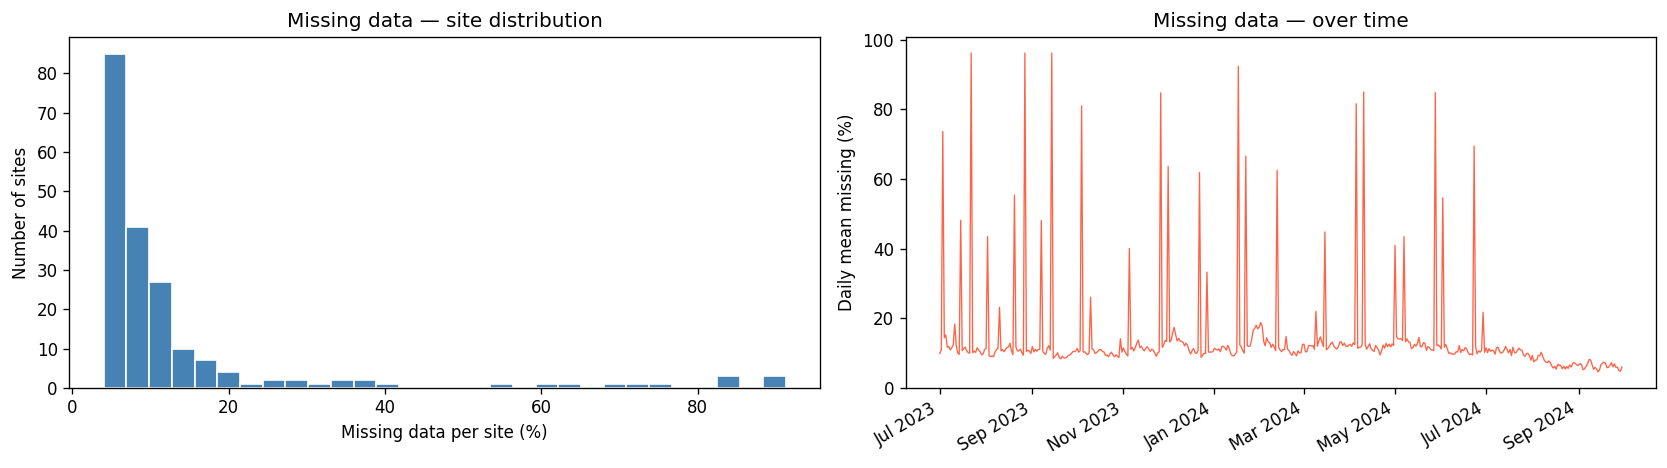

In [ ]:
missing_by_site = df.isna().mean() * 100
missing_by_day  = df.isna().resample('D').mean().mean(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(missing_by_site, bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Missing data per site (%)')
axes[0].set_ylabel('Number of sites')
axes[0].set_title('Missing data — site distribution')

axes[1].plot(missing_by_day.index, missing_by_day.values, color='tomato', lw=0.8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[1].set_ylabel('Daily mean missing (%)')
axes[1].set_title('Missing data — over time')

plt.tight_layout()
plt.show()

## 3. Site map

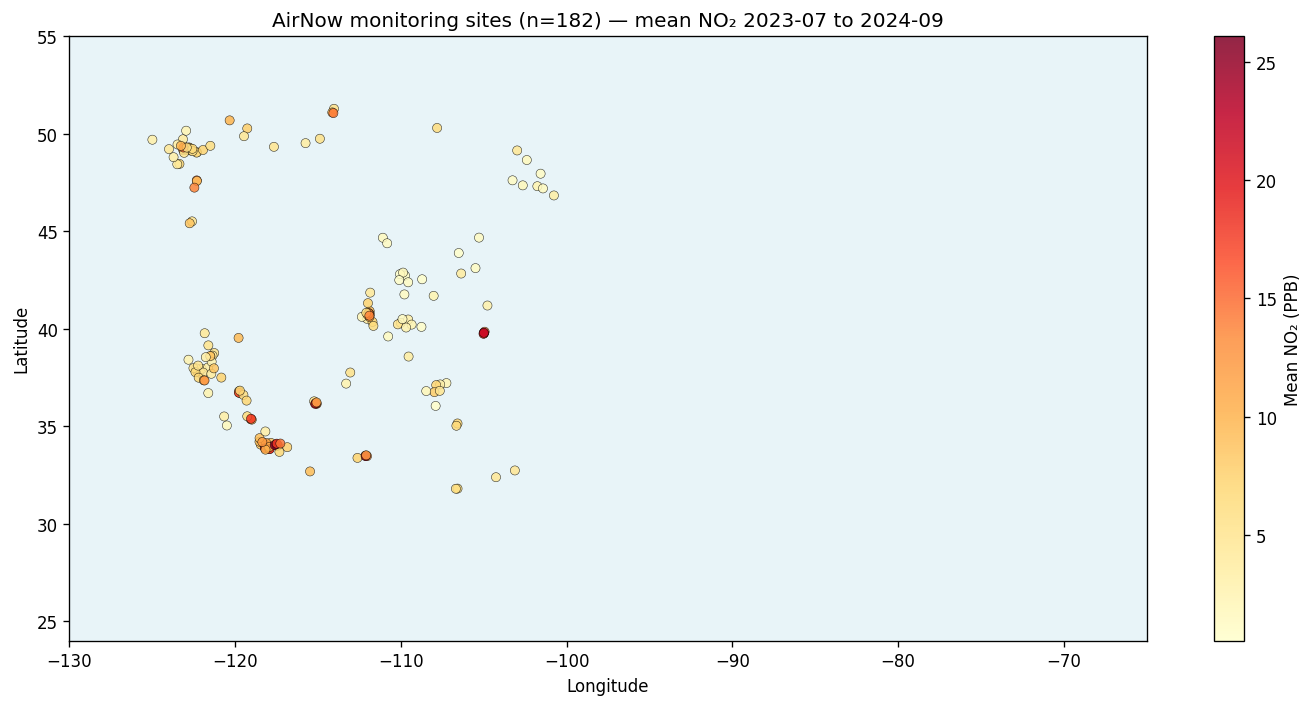

In [ ]:
# Only sites that appear in both meta and df
common = meta.index.intersection(df.columns)
meta_c = meta.loc[common]
mean_no2 = df[common].mean()

fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(
    meta_c['lon'], meta_c['lat'],
    c=mean_no2.loc[meta_c.index], cmap='YlOrRd',
    s=30, alpha=0.85, edgecolors='k', linewidths=0.3
)
plt.colorbar(sc, ax=ax, label='Mean NO₂ (PPB)')
ax.set_xlim(-130, -65)
ax.set_ylim(24, 55)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'AirNow monitoring sites (n={len(meta_c)}) — mean NO₂ 2023-07 to 2024-09')
ax.set_facecolor('#e8f4f8')
plt.tight_layout()
plt.show()

## 4. NO₂ time series — a few representative sites

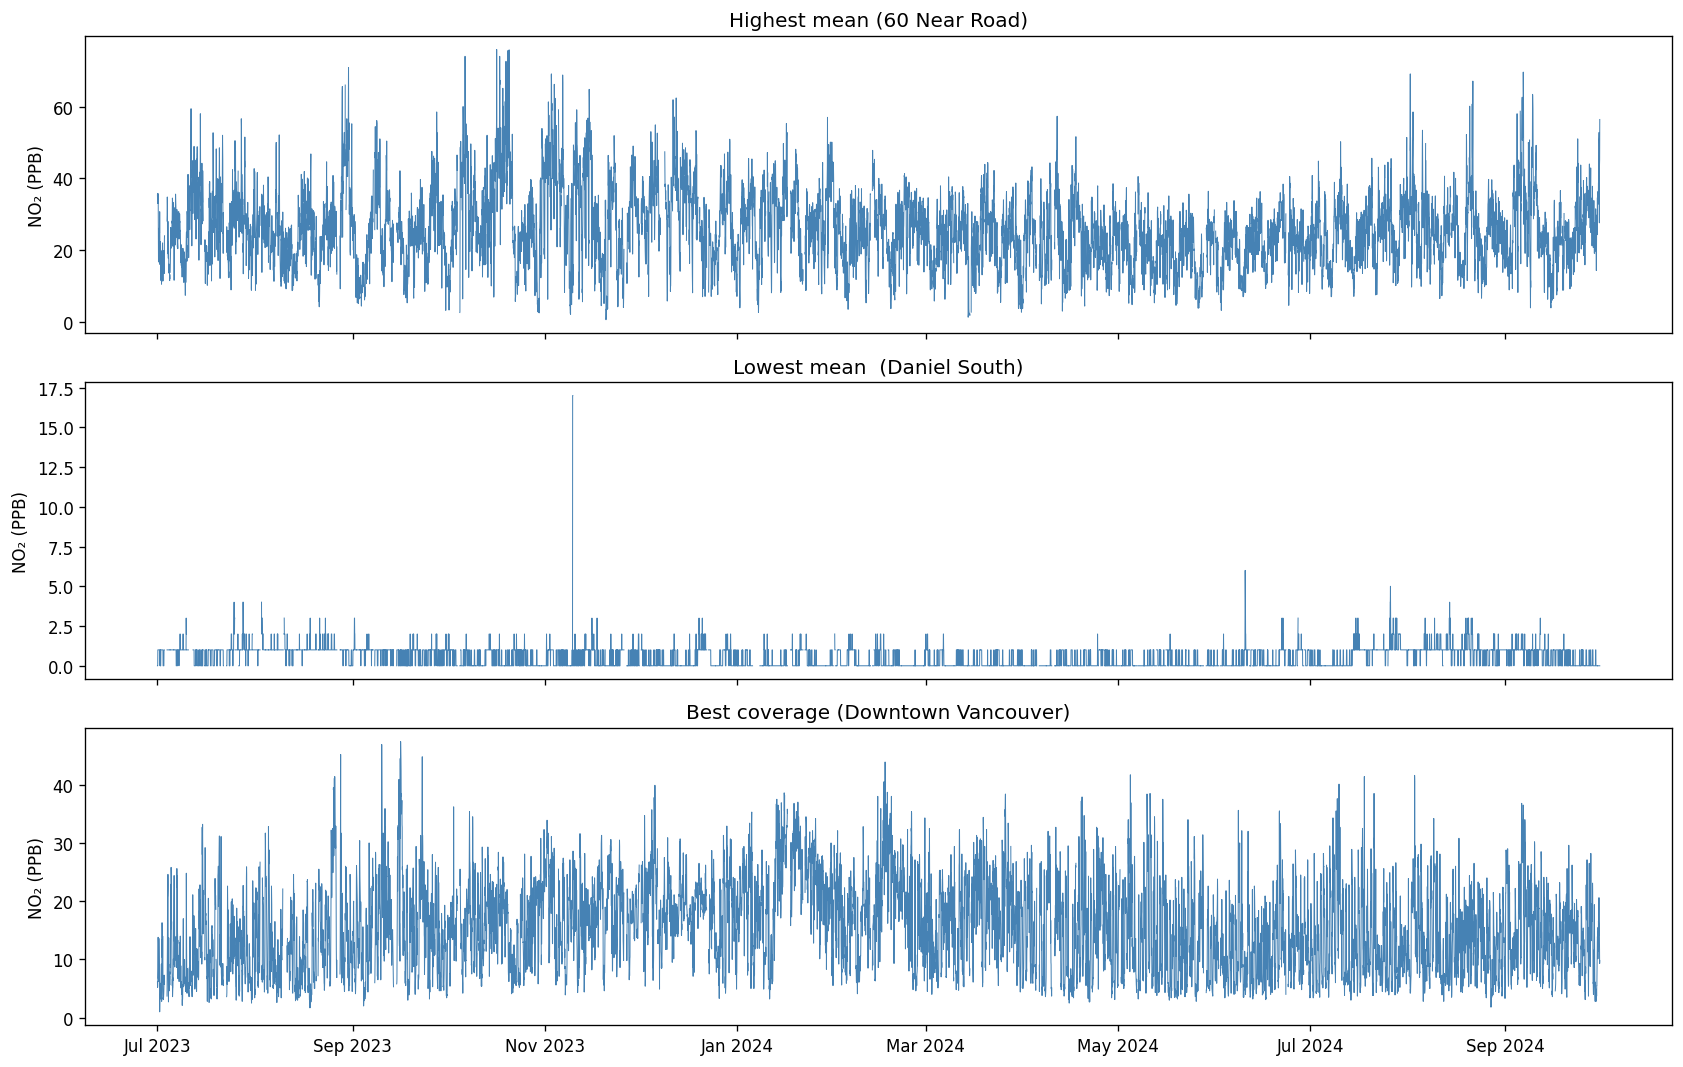

In [ ]:
# Pick 4 sites: highest mean, lowest mean, most complete, most missing
coverage    = df.notna().mean()
site_high   = mean_no2.idxmax()
site_low    = mean_no2[coverage > 0.5].idxmin()
site_best   = coverage.idxmax()
site_worst  = coverage[coverage > 0.1].idxmin()

showcase = {
    f'Highest mean ({meta.loc[site_high, "name"] if site_high in meta.index else site_high})': site_high,
    f'Lowest mean  ({meta.loc[site_low,  "name"] if site_low  in meta.index else site_low})':  site_low,
    f'Best coverage ({meta.loc[site_best, "name"] if site_best in meta.index else site_best})': site_best,
}

fig, axes = plt.subplots(len(showcase), 1, figsize=(14, 3*len(showcase)), sharex=True)
for ax, (label, site) in zip(axes, showcase.items()):
    ts = df[site].resample('h').mean()
    ax.plot(ts.index, ts.values, lw=0.6, color='steelblue')
    ax.set_ylabel('NO₂ (PPB)')
    ax.set_title(label)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

## 5. Diurnal cycle (average NO₂ by hour-of-day)

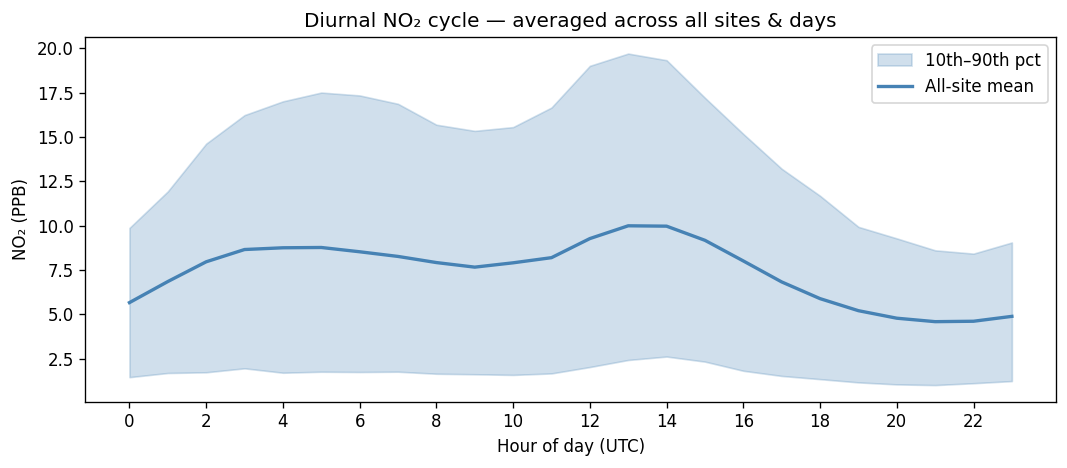

In [ ]:
diurnal = df.groupby(df.index.hour).mean()   # (24, n_sites)
diurnal_mean = diurnal.mean(axis=1)
diurnal_p10  = diurnal.quantile(0.10, axis=1)
diurnal_p90  = diurnal.quantile(0.90, axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(diurnal_mean.index, diurnal_p10, diurnal_p90,
                alpha=0.25, color='steelblue', label='10th–90th pct')
ax.plot(diurnal_mean.index, diurnal_mean.values, color='steelblue',
        lw=2, label='All-site mean')
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('NO₂ (PPB)')
ax.set_title('Diurnal NO₂ cycle — averaged across all sites & days')
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Monthly seasonal pattern

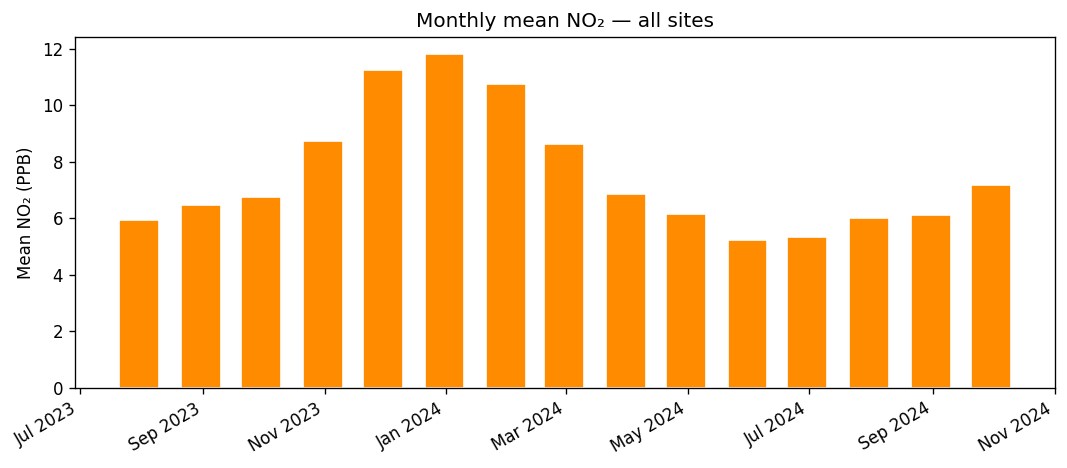

In [ ]:
monthly = df.resample('ME').mean().mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(monthly.index, monthly.values, width=20,
       color='darkorange', edgecolor='white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel('Mean NO₂ (PPB)')
ax.set_title('Monthly mean NO₂ — all sites')
plt.tight_layout()
plt.show()

## 7. Build sequences for training

In [ ]:
from data.load_airnow import load_sequences

SEQ_LEN  = 24    # look-back: 24 hours
PRED_LEN = 6     # forecast:   6 hours ahead

X, y, timestamps, sites = load_sequences(
    DATA_DIR, seq_len=SEQ_LEN, pred_len=PRED_LEN,
    normalize=True, fill_nan=0
)
print(f"X : {X.shape}   (windows × seq_len × n_sites)")
print(f"y : {y.shape}   (windows × pred_len × n_sites)")
print(f"Sites in sequences: {len(sites)}")

X : (10963, 24, 197)   (windows × seq_len × n_sites)
y : (10963, 6, 197)   (windows × pred_len × n_sites)
Sites in sequences: 197


In [ ]:
# Chronological train / val / test split (no shuffling — time series!)
n       = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X[:n_train],              y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],        y[n_train+n_val:]

print(f"Train : {X_train.shape[0]:>6} windows  |  {timestamps[0]} → {timestamps[n_train-1]}")
print(f"Val   : {X_val.shape[0]:>6} windows  |  {timestamps[n_train]} → {timestamps[n_train+n_val-1]}")
print(f"Test  : {X_test.shape[0]:>6} windows  |  {timestamps[n_train+n_val]} → {timestamps[-1]}")

Train :   7674 windows  |  2023-07-01 00:00:00 → 2024-05-15 17:00:00
Val   :   1644 windows  |  2024-05-15 18:00:00 → 2024-07-23 05:00:00
Test  :   1645 windows  |  2024-07-23 06:00:00 → 2024-09-29 18:00:00


## 8. Verify model forward passes

In [ ]:
import torch
from models.transformer_no2 import NO2Transformer
from models.mamba_no2 import NO2Mamba

N_SITES  = X.shape[2]
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")
print(f"Batch  : n_sites={N_SITES}, seq_len={SEQ_LEN}, pred_len={PRED_LEN}")

batch = torch.tensor(X[:8], dtype=torch.float32).to(DEVICE)

# Transformer
tf_model = NO2Transformer(n_sites=N_SITES, seq_len=SEQ_LEN, pred_len=PRED_LEN).to(DEVICE)
tf_out   = tf_model(batch)
print(f"\nTransformer output : {tuple(tf_out.shape)}  ✓" if tf_out.shape == (8, PRED_LEN, N_SITES)
      else f"Transformer output : {tuple(tf_out.shape)}  — unexpected!")
print(f"  Parameters       : {sum(p.numel() for p in tf_model.parameters()):,}")

# Mamba
mb_model = NO2Mamba(n_sites=N_SITES, seq_len=SEQ_LEN, pred_len=PRED_LEN).to(DEVICE)
mb_out   = mb_model(batch)
print(f"\nMamba output       : {tuple(mb_out.shape)}  ✓" if mb_out.shape == (8, PRED_LEN, N_SITES)
      else f"Mamba output       : {tuple(mb_out.shape)}  — unexpected!")
print(f"  Parameters       : {sum(p.numel() for p in mb_model.parameters()):,}")

/mnt/data3/isybelle1118/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Device : cpu
Batch  : n_sites=197, seq_len=24, pred_len=6

Transformer output : (8, 6, 197)  ✓
  Parameters       : 3,922,590

Mamba output       : (8, 6, 197)  ✓
  Parameters       : 4,020,126


## 9. Quick training smoke-test (5 epochs)

Trains both models for 5 epochs on a small subset — verifies the training loop works end-to-end before running a full training run.

In [ ]:
from models.transformer_no2 import train, evaluate

# Use a small subset for the smoke-test
Xs = X_train[:2000];  ys = y_train[:2000]
Xv = X_val[:500];     yv = y_val[:500]

print("=== Transformer (smoke-test) ===")
tf_model = NO2Transformer(n_sites=N_SITES, seq_len=SEQ_LEN, pred_len=PRED_LEN)
train(tf_model, Xs, ys, Xv, yv, epochs=5, batch_size=64, lr=1e-3)

print("\n=== Mamba (smoke-test) ===")
mb_model = NO2Mamba(n_sites=N_SITES, seq_len=SEQ_LEN, pred_len=PRED_LEN)
train(mb_model, Xs, ys, Xv, yv, epochs=5, batch_size=64, lr=1e-3)

=== Transformer (smoke-test) ===
Epoch   1 | train MSE=0.7113 val MSE=1.2153 MAE=0.5840
Epoch   2 | train MSE=0.4398 val MSE=1.1738 MAE=0.5626
Epoch   3 | train MSE=0.3715 val MSE=1.2382 MAE=0.6170
Epoch   4 | train MSE=0.3268 val MSE=1.3120 MAE=0.6592
Epoch   5 | train MSE=0.2922 val MSE=1.2760 MAE=0.6357

=== Mamba (smoke-test) ===


In [ ]:
# Evaluate smoke-test models on the test slice
Xt = X_test[:500];  yt = y_test[:500]

tf_mse, tf_mae = evaluate(tf_model, Xt, yt)
mb_mse, mb_mae = evaluate(mb_model, Xt, yt)

print(f"{'Model':<15} {'MSE':>10} {'MAE':>10}")
print("-" * 37)
print(f"{'Transformer':<15} {tf_mse:>10.4f} {tf_mae:>10.4f}")
print(f"{'Mamba':<15} {mb_mse:>10.4f} {mb_mae:>10.4f}")
print("\n(5-epoch smoke-test only — run full training for meaningful comparison)")

Model                  MSE        MAE
-------------------------------------
Transformer         2.1216     0.7651
Mamba               2.8144     1.0368

(5-epoch smoke-test only — run full training for meaningful comparison)


## 10. Daily mean NO₂ time series

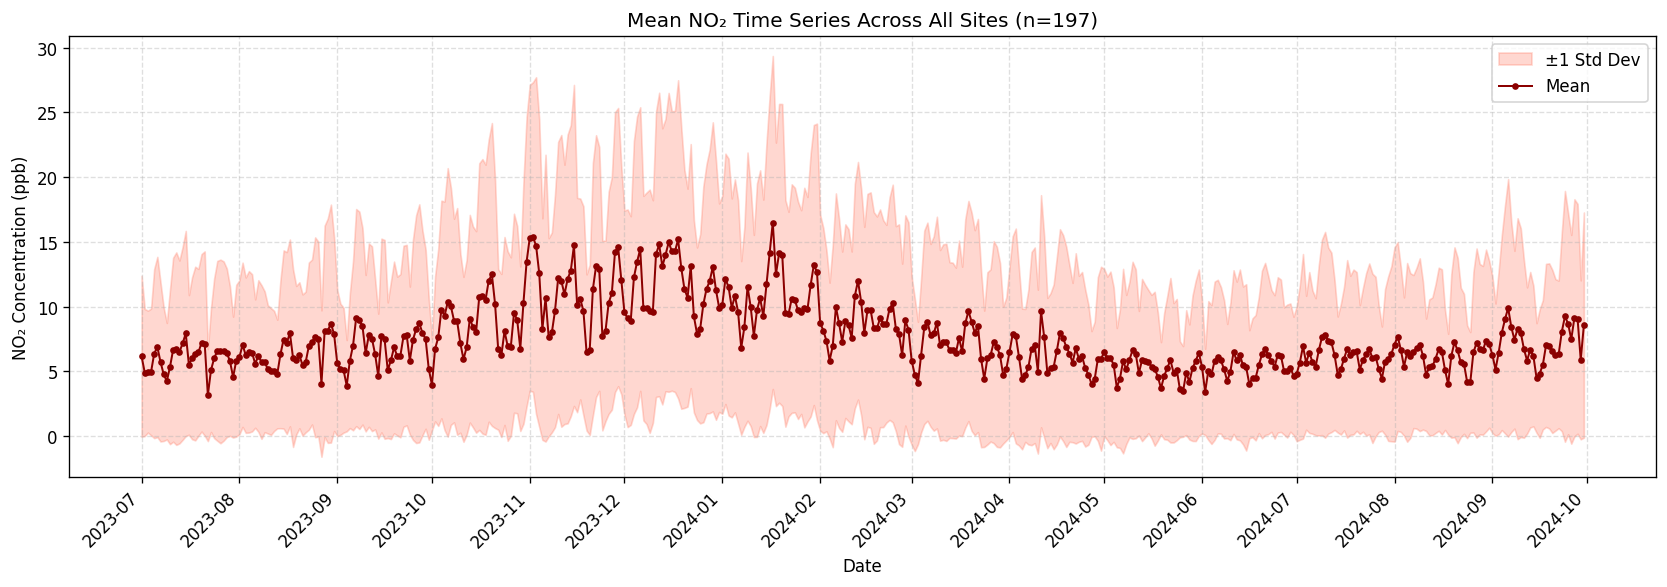

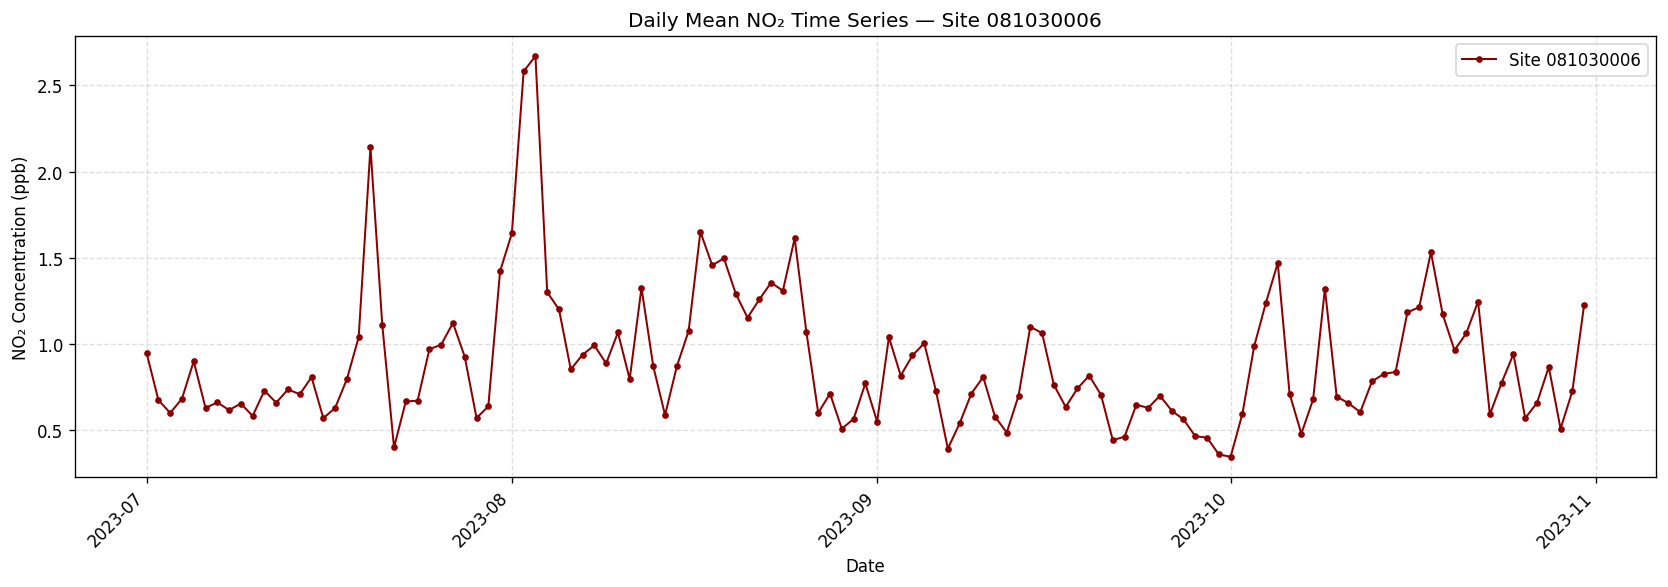

In [ ]:

SITE = '081030006'

daily_site = df[SITE].resample('D').mean()
daily_all  = df.mean(axis=1).resample('D').mean()
daily_std  = df.std(axis=1).resample('D').mean()

# ── All-sites plot (styled like reference image) ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(daily_all.index,
                daily_all - daily_std,
                daily_all + daily_std,
                color='blue', alpha=0.25, label='±1 Std Dev')
ax.plot(daily_all.index, daily_all.values,
        color='blue', lw=1.2, marker='o', markersize=3, label='Mean')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('NO₂ Concentration (ppb)')
ax.set_title('Mean NO₂ Time Series Across All Sites (n=197)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Site-specific plot ────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 5))

ax2.plot(daily_site.index, daily_site.values,
         color='blue', lw=1.2, marker='o', markersize=3, label=f'Site {SITE}')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.set_xlabel('Date')
ax2.set_ylabel('NO₂ Concentration (ppb)')
ax2.set_title(f'Daily Mean NO₂ Time Series — Site {SITE}')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
